# ETAPA 2: Análisis exploratorio y perfilado
# Objetivo: Explorar la evolución de los datos y realizar análisis comparativos.
# Rango temporal: 6 meses de datos (enero–junio 2020).
## Dificultad: Media – combinar múltiples archivos y realizar cálculos agregados. bold text

1. ¿Cuáles son los 10 países con más casos confirmados acumulados durante el semestre?

In [1]:
# En caso de que las librerías no estén instaladas, descomenta las siguientes líneas

#%pip install pandas
#%pip install numpy
#%pip install matplotlib
#%pip install seaborn
#%pip install time
#%pip install dask

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'
import matplotlib as mpl
import seaborn as sb
from IPython.display import display

import time
import os
import dask.dataframe as dd

pd.set_option('display.max_columns', None)

In [3]:
# Define the start and end dates (6 primeros meses del 2021)
start_date = '2021-01-01'
end_date = '2021-6-30'

date_range = pd.date_range(start=start_date, end=end_date)

urls = [f'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/refs/heads/master/csse_covid_19_data/csse_covid_19_daily_reports/{single_date.strftime("%m-%d-%Y")}.csv' for single_date in date_range]
df = []
df2 = []

In [4]:
# Importar 6 primeros meses del 2021 - forma 1

# Definir lista de DF's y tiempo inicial de carga
start_time = time.time()

for url in urls:
    df.append(pd.read_csv(url))

# Combinar los DataFrames diarios en uno solo.
seisMeses = pd.concat(df, ignore_index=True)

# Calcular tiempo de carga
load_time_1 = time.time() - start_time
print(f"Tiempo de carga: {load_time_1:.2f} s")

Tiempo de carga: 16.20 s


In [5]:
# Importar 6 primeros meses del 2021 - forma 2 (con Dask)

# Definir lista de DF's y tiempo inicial de carga
start_time = time.time()

# Leer todos los archivos en paralelo con Dask
seisMeses = dd.read_csv(urls, dtype={'Admin2': 'object', 'FIPS': 'object'}, assume_missing=True)

# Calcular tiempo de carga
load_time_2 = time.time() - start_time
print(f"Tiempo de carga con Dask: {load_time_2:.2f} s")

Tiempo de carga con Dask: 2.15 s


In [6]:
# Uso de memoria antes de conversión de tipos

seisMeses_pd = seisMeses.compute()

# Verificar memoria usada por el DataFrame pandas resultante
memoria = seisMeses_pd.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"Memoria usada del DataFrame: {memoria:.2f} MB")

Memoria usada del DataFrame: 125.18 MB


In [ ]:
# Uso de memoria después de conversión de tipos

# Convertir columnas a tipos más eficientes
seisMeses['Province_State'] = seisMeses['Province_State'].astype('category')
seisMeses['Country_Region'] = seisMeses['Country_Region'].astype('category')
seisMeses['Combined_Key'] = seisMeses['Combined_Key'].astype('category')

# Eliminar columnas innecesarias
seisMeses = seisMeses.drop(columns=['FIPS', 'Admin2', 'Lat', 'Long_', 'Combined_Key'])

seisMeses_pd = seisMeses.compute()

# Verificar memoria usada por el DataFrame pandas resultante
memoria_optimizacion = seisMeses_pd.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"Memoria usada del DataFrame tras optimización: {memoria_optimizacion:.2f} MB")

Memoria usada del seisMeses_pdf tras optimización: 60.31 MB


In [8]:
print(f"Diferencia en uso de memoria: {(-(memoria - memoria_optimizacion) * 100 / memoria):.0f}%")

Diferencia en uso de memoria: -52%


In [9]:
seisMeses = seisMeses.compute()

In [72]:
paisGrouped = seisMeses.groupby('Country_Region')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()

/tmp/ipykernel_636/2788665832.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  paisGrouped = seisMeses.groupby('Country_Region')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()


1. ¿Cuáles son los 10 países con más casos confirmados acumulados durante el semestre?

In [73]:
paisGrouped[['Country_Region', 'Confirmed']].sort_values(by='Confirmed', ascending=False).head(10)

,Country_Region,Confirmed
185,US,"5,412,065,912"
80,India,"3,085,844,316"
24,Brazil,"2,326,197,586"
63,France,"831,568,058"
146,Russia,"802,529,033"
189,United Kingdom,"757,138,369"
183,Turkey,"678,964,897"
86,Italy,"621,181,216"
166,Spain,"582,139,639"
67,Germany,"523,778,221"


2. ¿Qué países presentan mayor tasa de letalidad (Deaths / Confirmed * 100)?

In [74]:
%%time

tabla_letalidad = paisGrouped[['Country_Region', 'Deaths', 'Confirmed']]
tabla_letalidad = tabla_letalidad[tabla_letalidad['Confirmed'] > 0].copy()  # evitar división por cero
tabla_letalidad['tasa_letalidad'] = (tabla_letalidad['Deaths'] / tabla_letalidad['Confirmed']) * 100
tabla_letalidad = tabla_letalidad.rename(columns={'Confirmed': "Confirmados", 'Deaths': "Muertes"})
tabla_letalidad.sort_values(by='tasa_letalidad', ascending=False).head(10)

CPU times: user 2.72 ms, sys: 0 ns, total: 2.72 ms
Wall time: 2.49 ms


CPU times: user 2.72 ms, sys: 0 ns, total: 2.72 ms
Wall time: 2.49 ms


,Country_Region,Muertes,Confirmados,tasa_letalidad
107,MS Zaandam,362,"1,629",22
197,Yemen,"171,685","798,884",21
192,Vanuatu,71,482,15
140,Peru,"26,112,846","280,726,440",9
117,Mexico,"35,350,954","390,216,776",9
173,Syria,"238,030","3,451,966",7
168,Sudan,"386,145","5,803,941",7
54,Egypt,"2,191,056","37,901,381",6
53,Ecuador,"3,151,408","60,650,020",5
163,Somalia,"86,378","1,870,995",5


3. ¿Cuántos países no registran recuperados en los datos analizados?

In [75]:
#Revisar bien porque cuenta todos los 0, no solo los del recuperado, es una serie
totalRecuperadosPais = paisGrouped['Recovered']
NoRecuperados = (totalRecuperadosPais == 0).sum()
print('En total hay ', NoRecuperados,' paises que no registran recuperados en esos 6 meses')

En total hay  13  paises que no registran recuperados en esos 6 meses


4. ¿Qué país latinoamericano presenta la mayor cantidad de casos activos en junio 2020?

In [76]:
# Lista de países latinoamericanos
paises_latinoamerica = [
    'Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Costa Rica', 'Cuba', 'Dominican Republic',
    'Ecuador', 'El Salvador', 'Guatemala', 'Haiti', 'Honduras', 'Mexico', 'Nicaragua', 'Panama',
    'Paraguay', 'Peru', 'Uruguay', 'Venezuela'
]

# Filtrar tablaActivos para países latinoamericanos
activos = paisGrouped[['Country_Region', 'Active']].copy()

tablaActivos_latam = activos[activos['Country_Region'].isin(paises_latinoamerica)]

# Encontrar el país con más casos activos
mayorActivos = tablaActivos_latam['Active'].idxmax()
pais_mayor = tablaActivos_latam.loc[mayorActivos, 'Country_Region']
activos_mayor = tablaActivos_latam.loc[mayorActivos, 'Active']

print(f'El país latinoamericano con la mayor cantidad de casos activos en junio de 2020 es {pais_mayor} con {activos_mayor} casos activos.')

El país latinoamericano con la mayor cantidad de casos activos en junio de 2020 es Mexico con 354865822.0 casos activos.


5. ¿Cómo evolucionaron los casos confirmados en Chile entre seisMeses y junio? (gráfico de
líneas).

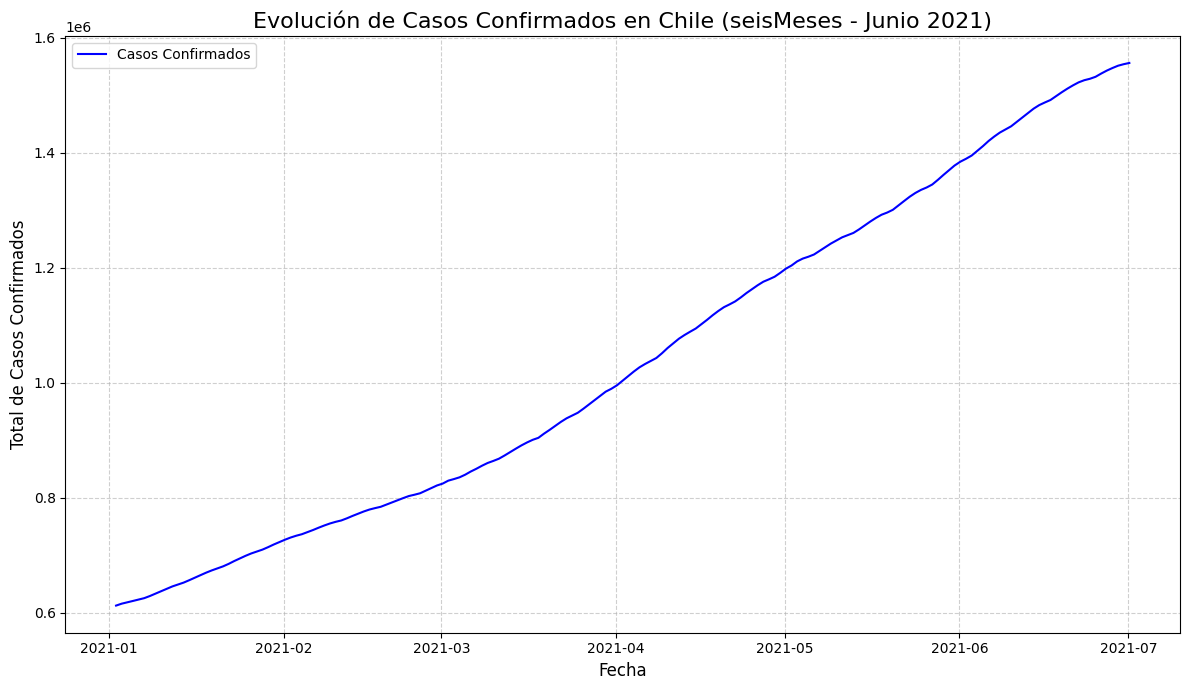

In [77]:
datosChile = seisMeses.loc[seisMeses['Country_Region'] == 'Chile'].copy()
datosChile['Last_Update'] = pd.to_datetime(datosChile['Last_Update'])
datosAgrupados = datosChile.groupby(datosChile['Last_Update'])['Confirmed'].sum().reset_index()
datosAgrupados

plt.figure(figsize=(12, 7))
plt.plot(datosAgrupados['Last_Update'], datosAgrupados['Confirmed'], label='Casos Confirmados', color='b')

plt.title('Evolución de Casos Confirmados en Chile (seisMeses - Junio 2021)', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Total de Casos Confirmados', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()


6. ¿Cuál fue la fecha con más nuevos casos a nivel mundial durante este período?

In [78]:
casosNuevos = seisMeses[['Country_Region','Last_Update','Confirmed']].copy()
casosNuevos['Last_Update'] = pd.to_datetime(casosNuevos['Last_Update'], format='ISO8601')

casosNuevos['Last_Update'] = casosNuevos['Last_Update'].dt.date

casosNuevos_mundial = casosNuevos.groupby('Last_Update')['Confirmed'].sum().reset_index()
casosNuevos_mundial['Nuevos Casos'] = casosNuevos_mundial['Confirmed'].diff()

fila_max_nuevos = casosNuevos_mundial.loc[casosNuevos_mundial['Nuevos Casos'].idxmax()]

fecha_max = fila_max_nuevos['Last_Update']
casos_max = fila_max_nuevos['Nuevos Casos']

print(f"\nLa fecha con más nuevos casos reportados a nivel mundial fue: {fecha_max}, con un total de {int(casos_max):,} casos nuevos")


La fecha con más nuevos casos reportados a nivel mundial fue: 2021-01-02, con un total de 84,323,180 casos nuevos


7. ¿Existe correlación entre casos confirmados y fallecidos? (gráfico de dispersión +
regresión).

In [79]:
cols_to_plot = ['Confirmed', 'Deaths']
seisMeses_paises = seisMeses.copy()

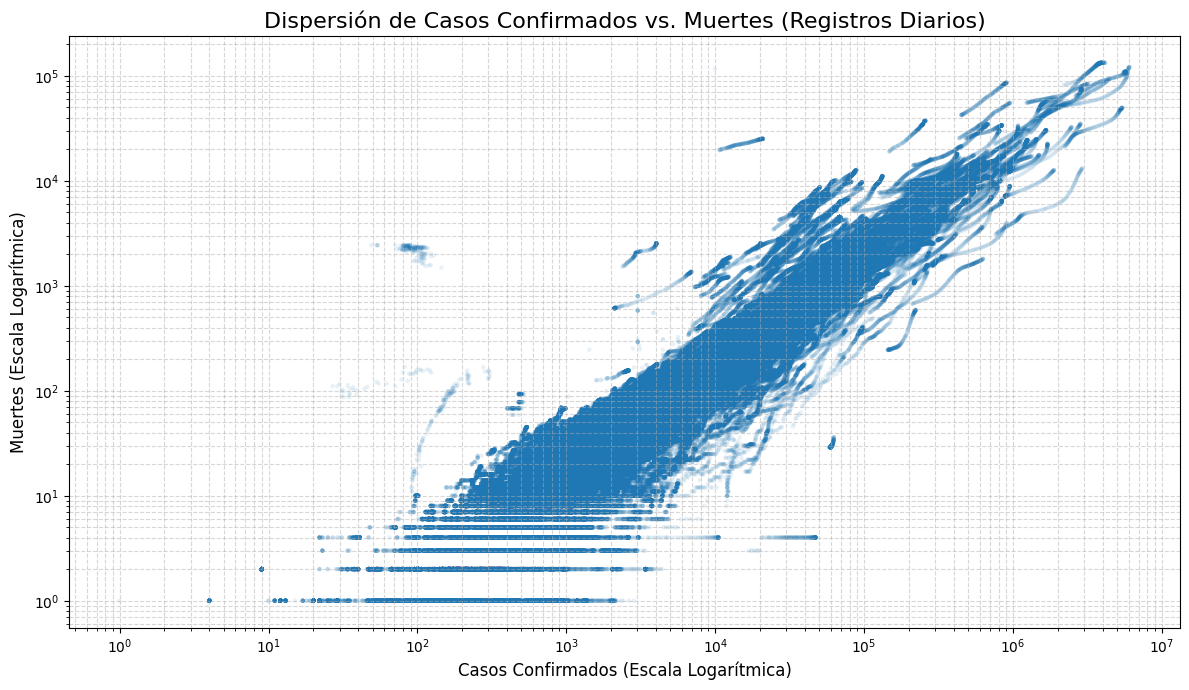

In [80]:
plt.figure(figsize=(12, 7))

# Usamos sns.scatterplot (en lugar de regplot)
# 'alpha=0.1' hace los puntos 90% transparentes para ver la densidad
# 's=10' hace los puntos más pequeños
sb.scatterplot(
    data=seisMeses_paises, 
    x='Confirmed', 
    y='Deaths',
    alpha=0.1, 
    s=10,
    edgecolor='none' # Quitar bordes de los puntos
)

# ¡¡Crucial!! Usar escala logarítmica para que los datos se separen
plt.xscale('log')
plt.yscale('log')

plt.title('Dispersión de Casos Confirmados vs. Muertes (Registros Diarios)', fontsize=16)
plt.xlabel('Casos Confirmados (Escala Logarítmica)', fontsize=12)
plt.ylabel('Muertes (Escala Logarítmica)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5, which='both') 
plt.tight_layout()

Gráfico guardado exitosamente como: grafico_regresion_por_pais.png


Gráfico guardado exitosamente como: grafico_regresion_por_pais.png


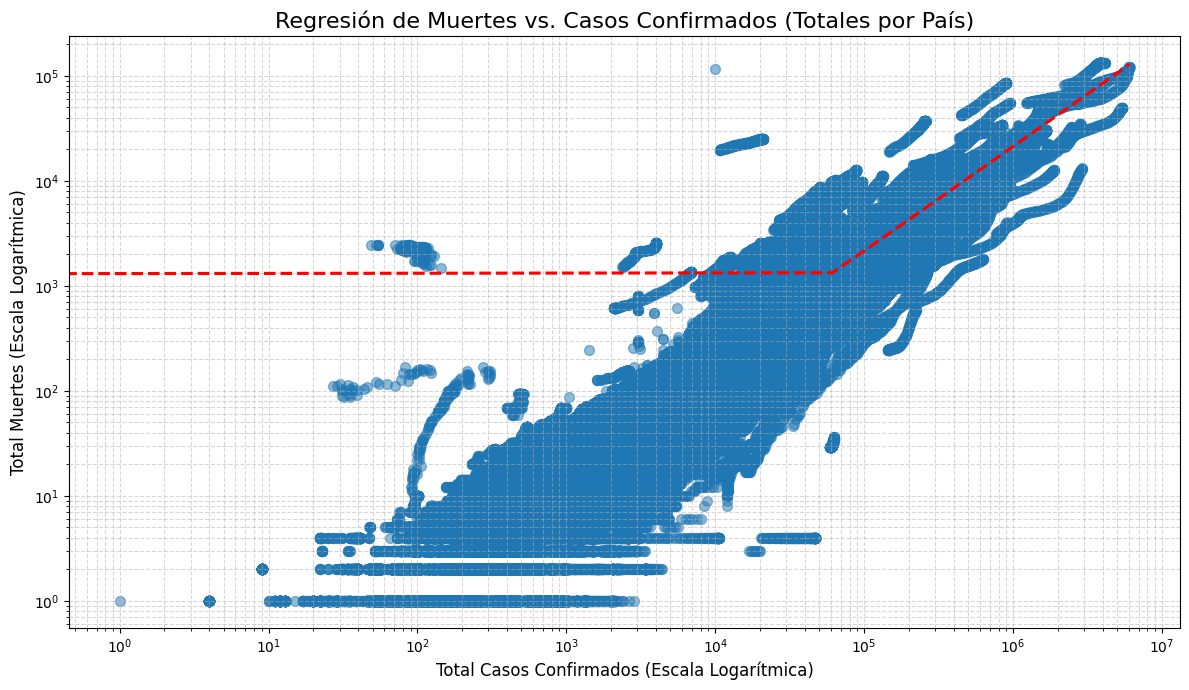

In [81]:
plt.figure(figsize=(12, 7))

# sns.regplot() dibuja los puntos Y la línea de regresión
sb.regplot(
    data=seisMeses_paises, 
    x='Confirmed', 
    y='Deaths',
    scatter_kws={'alpha': 0.5, 's': 50},       # Estilo de los puntos
    line_kws={'color': 'red', 'linestyle': '--'} # Estilo de la línea
)

plt.xscale('log')
plt.yscale('log')

plt.title('Regresión de Muertes vs. Casos Confirmados (Totales por País)', fontsize=16)
plt.xlabel('Total Casos Confirmados (Escala Logarítmica)', fontsize=12)
plt.ylabel('Total Muertes (Escala Logarítmica)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5, which='both')
plt.tight_layout()

# Guardar el Gráfico
output_filename = 'grafico_regresion_por_pais.png'
plt.savefig(output_filename)
print(f"Gráfico guardado exitosamente como: {output_filename}")

8. Mostrar el Top 10 de países con mayor crecimiento porcentual de casos entre mayo y
junio.

In [82]:
mayorCrecimiento = seisMeses.copy()
mayorCrecimiento['Last_Update'] = pd.to_datetime(mayorCrecimiento['Last_Update'], format='ISO8601')
crecimientoDaily = mayorCrecimiento.groupby(['Country_Region', 'Last_Update'])['Confirmed'].sum().reset_index()

fecha_mayo = pd.to_datetime('2021-05-31')
fecha_junio = pd.to_datetime('2021-06-30')

#Crecimiento historico finales de mayo.
df_mayo_historico = crecimientoDaily[crecimientoDaily['Last_Update'] <= fecha_mayo]
df_mayo_final = df_mayo_historico.groupby('Country_Region')['Confirmed'].max().reset_index()
df_mayo_final.columns = ['Country_Region', 'Total_Mayo']

#crecimiento historico finales de junio
df_junio_historico = crecimientoDaily[crecimientoDaily['Last_Update'] <= fecha_junio]
df_junio_final = df_junio_historico.groupby('Country_Region')['Confirmed'].max().reset_index()
df_junio_final.columns = ['Country_Region', 'Total_Junio']

crecimientoTotal = pd.merge(df_mayo_final, df_junio_final, on='Country_Region', how='inner')
threshold = 100
df_growth_filtrado = crecimientoTotal[crecimientoTotal['Total_Mayo'] > threshold]

df_growth_filtrado['Crecimiento_Porc'] = ((df_growth_filtrado['Total_Junio'] - df_growth_filtrado['Total_Mayo']) / df_growth_filtrado['Total_Mayo']) * 100
df_top10 = df_growth_filtrado.sort_values(by='Crecimiento_Porc', ascending=False).head(10)
df_top10


/tmp/ipykernel_636/518184229.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  crecimientoDaily = mayorCrecimiento.groupby(['Country_Region', 'Last_Update'])['Confirmed'].sum().reset_index()
/tmp/ipykernel_636/518184229.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mayo_final = df_mayo_historico.groupby('Country_Region')['Confirmed'].max().reset_index()
/tmp/ipykernel_636/518184229.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default an

,Country_Region,Total_Mayo,Total_Junio,Crecimiento_Porc
61,Fiji,360,"3,832",964
194,Vietnam,"6,908","16,136",134
120,Mongolia,"56,621","111,505",97
174,Taiwan*,"7,806","14,694",88
186,Uganda,"45,931","79,089",72
102,Liberia,"2,179","3,736",71
31,Cambodia,"28,825","48,532",68
177,Thailand,"149,779","249,853",67
0,Afghanistan,"70,111","115,751",65
124,Namibia,"54,659","86,649",59


9. Identificar países con rebrote (un día sin casos y luego un incremento posterior).

In [83]:
rebrote = seisMeses.copy()
rebrote['Last_Update'] = pd.to_datetime(rebrote['Last_Update'], format='ISO8601')

rebrote = rebrote.sort_values(by=['Country_Region', 'Last_Update'])
rebrote['Nuevos_Casos'] = rebrote.groupby('Country_Region')['Confirmed'].diff()

rebrote['Nuevos_Casos'] = rebrote['Nuevos_Casos'].fillna(rebrote['Confirmed'])
rebrote['Nuevos_Casos'] = rebrote['Nuevos_Casos'].clip(lower=0)

/tmp/ipykernel_636/1550063919.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rebrote['Nuevos_Casos'] = rebrote.groupby('Country_Region')['Confirmed'].diff()


In [84]:
paises_con_rebrote = []
datos_agrupados = rebrote.groupby('Country_Region')
for nombre_pais, datos_pais in datos_agrupados:
    
    # Obtener todas las fechas donde hubo 0 casos nuevos
    fechas_cero_casos = datos_pais[datos_pais['Nuevos_Casos'] == 0]['Last_Update']
    
    # Si nunca tuvo un día con 0 casos, no puede tener rebrote
    if fechas_cero_casos.empty:
        continue
        
    # Encontrar la PRIMERA fecha con 0 casos
    primera_fecha_cero = fechas_cero_casos.min()
    
    # Buscar si existe CUALQUIER día POSTERIOR con casos > 0
    # Construir una máscara booleana y aplicar .any() sobre la serie booleana
    mask = (datos_pais['Last_Update'] > primera_fecha_cero) & (datos_pais['Nuevos_Casos'] > 0)
    tiene_crecimiento_posterior = mask.any()
    
    if tiene_crecimiento_posterior:
        paises_con_rebrote.append(nombre_pais)

# --- 5. Mostrar Resultados ---

print("\n--- Países Identificados con Rebrote ---")
if paises_con_rebrote:
    for pais in paises_con_rebrote:
        print(f"- {pais}")
else:
    print("No se encontraron países con el patrón de rebrote especificado.")


--- Países Identificados con Rebrote ---
- Afghanistan
- Albania
- Algeria
- Andorra
- Antigua and Barbuda
- Australia
- Bahamas
- Barbados
- Belgium
- Belize
- Benin
- Bhutan
- Bolivia
- Bosnia and Herzegovina
- Botswana
- Brazil
- Brunei
- Bulgaria
- Burkina Faso
- Burma
- Burundi
- Cabo Verde
- Cambodia
- Cameroon
- Canada
- Central African Republic
- Chad
- Chile
- China
- Colombia
- Comoros
- Congo (Brazzaville)
- Congo (Kinshasa)
- Costa Rica
- Cote d'Ivoire
- Czechia
- Denmark
- Djibouti
- Dominica
- El Salvador
- Equatorial Guinea
- Eritrea
- Eswatini
- Fiji
- France
- Gabon
- Gambia
- Germany
- Ghana
- Greece
- Grenada
- Guatemala
- Guinea
- Guinea-Bissau
- Guyana
- Haiti
- Honduras
- Hungary
- Iceland
- India
- Israel
- Italy
- Japan
- Jordan
- Kazakhstan
- Kiribati
- Kosovo
- Kyrgyzstan
- Laos
- Lebanon
- Lesotho
- Liberia
- Libya
- Liechtenstein
- Luxembourg
- Madagascar
- Malawi
- Malaysia
- Mali
- Malta
- Mauritania
- Mauritius
- Mexico
- Monaco
- Mozambique
- Namibia
- 

/tmp/ipykernel_636/1334590618.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  datos_agrupados = rebrote.groupby('Country_Region')


10. Generar un reporte de perfilado automático (ydata-profiling o pandas_profiling) que incluya
distribuciones, correlaciones y resumen de calidad de datos.

In [85]:
# Instalar la librería si no está disponible
#%pip install -q ydata-profiling

In [22]:
# Preparar y generar reporte de perfil de forma robusta (reemplaza la celda actual de profiling)

# Elegir muestra si el DataFrame es grande para evitar OOM en máquinas locales
try:
    from ydata_profiling import ProfileReport
except Exception:
    # En Jupyter, usar magic para instalar si falta (descomenta si necesitas)
    # %pip install -q ydata-profiling
    raise

n_rows = len(seisMeses)
sample_threshold = 100_000   # si > threshold usar muestra
sample_size = 10_000

if n_rows > sample_threshold:
    print(f"Dataset grande ({n_rows} filas). Usando muestra de {sample_size} filas para el perfilado.")
    df_for_profile = seisMeses.sample(sample_size, random_state=0)
else:
    print(f"Dataset pequeño/moderado ({n_rows} filas). Usando todo el DataFrame para el perfilado.")
    df_for_profile = seisMeses

# Configurar reporte (minimal para rapidez; aumenta opciones si tienes memoria)
profile = ProfileReport(df_for_profile,
                        title="Reporte de Perfilado - Datos COVID",
                        explorative=False,
                        minimal=True)

output_file = "perfilado.html"
try:
    if os.path.exists(output_file):
        os.remove(output_file)
    profile.to_file(output_file)
    if os.path.exists(output_file):
        size_mb = os.path.getsize(output_file) / (1024*1024)
        print(f"Reporte guardado en: {os.path.abspath(output_file)}  (tamaño: {size_mb:.2f} MB)")
    else:
        print("El proceso terminó sin error aparente, pero no se encontró el archivo en disco.")
except Exception as e:
    print("Error generando el reporte de perfilado:", e)
    # opcional: intentar guardar en otra ruta o con menor configuración
    try:
        alt_file = "perfilado_backup.html"
        profile.to_file(alt_file)
        print(f"Reporte guardado en copia: {os.path.abspath(alt_file)}")
    except Exception as e2:
        print("Fallo también al intentar guardar copia:", e2)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:01<00:00,  4.76it/s]



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:01<00:00,  4.76it/s]



Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

...

100%|██████████| 9/9 [00:01<00:00,  4.76it/s]



Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]


--- ¡Reporte Generado! ---
CPU times: user 3.66 s, sys: 468 ms, total: 4.13 s
Wall time: 4.14 s
